# Buildbot Analysis for LLM Paper: Engagement Data (T7)
This notebook analyzes the qualitative assessments of children's interactions with the LLM (Marty) at timepoint T7.
Variables analyzed:
1. LLM_enjoyment: How did you like your last voice interaction with Marty? (1-5)
2. LLM_learning: How much did your last conversation with Marty help you learn? (1-5)
3. LLM_contributions: Did you feel everyone talked to Marty equally? (1-4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 12

In [2]:
# Load data with ISO-8859-1 encoding
data_path = Path('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv')
df = pd.read_csv(data_path, encoding='ISO-8859-1')

# Filter for T7 (Post-session LLM interaction)
df_t7 = df[df['Timepoint'] == 'T7'].copy()

print(f"Total responses at T7: {len(df_t7)}")
df_t7[['LLM_enjoyment', 'LLM_learning', 'LLM_contributions']].describe()

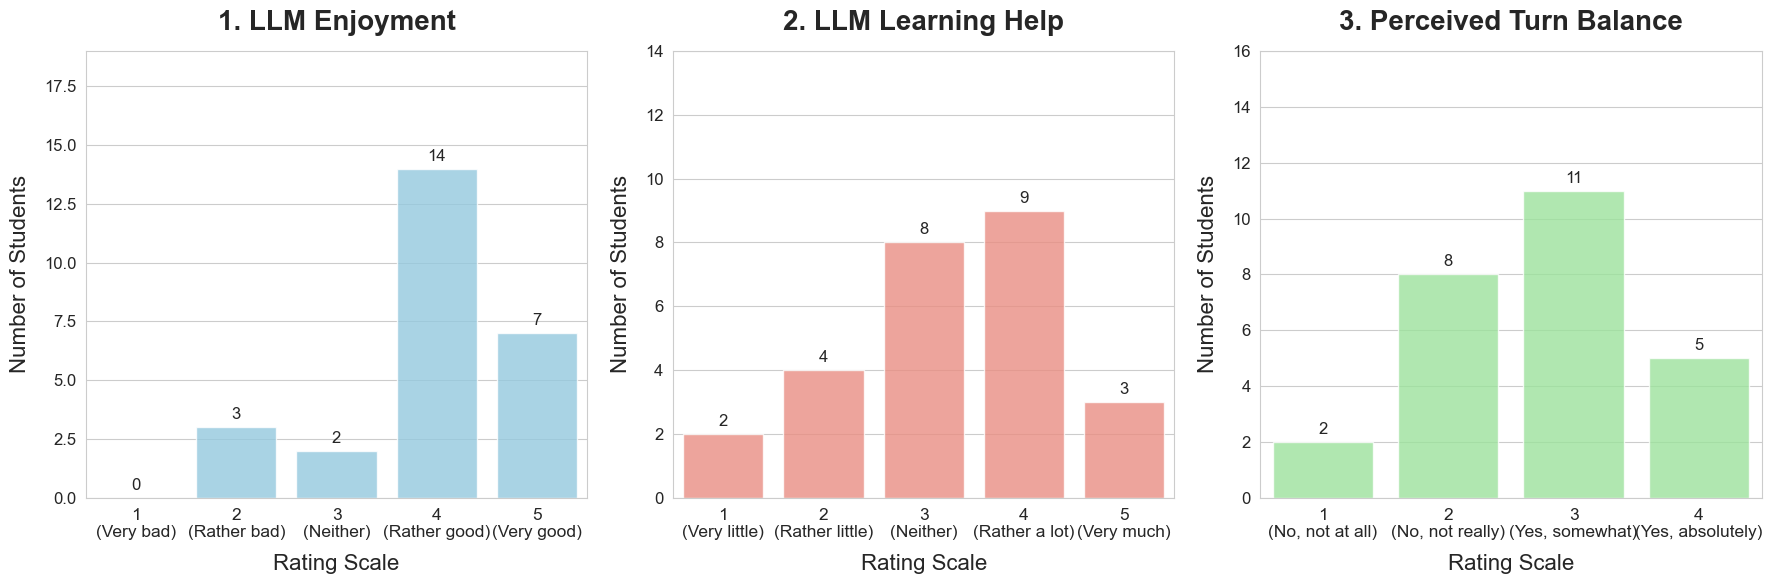

In [28]:
# Define qualitative labels for our 3 metrics
enjoyment_labels = {1: 'Very bad', 2: 'Rather bad', 3: 'Neither', 4: 'Rather good', 5: 'Very good'}
learning_labels = {1: 'Very little', 2: 'Rather little', 3: 'Neither', 4: 'Rather a lot', 5: 'Very much'}
contribution_labels = {1: 'No, not at all', 2: 'No, not really', 3: 'Yes, somewhat', 4: 'Yes, absolutely'}

def plot_distribution(data, column, title, labels_map, color, subplot_idx):
    plt.subplot(1, 3, subplot_idx)
    
    # Ensure all scale points (1-5 or 1-4) are shown, even if they have 0 counts
    possible_values = sorted(labels_map.keys())
    counts = data[column].value_counts().reindex(possible_values).fillna(0)
    
    # Create the bar plot
    ax = sns.barplot(x=counts.index, y=counts.values, color=color, alpha=0.8)
    
    plt.title(title, fontweight='bold', pad=15, fontsize=20)
    plt.xlabel('Rating Scale', fontsize=16, labelpad=10)
    plt.ylabel('Number of Students', fontsize=16, labelpad=10)
    plt.ylim(0, counts.max() + 5) # Add space for labels
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')
    
    # Replace numeric ticks with our qualitative labels
    plt.xticks(ticks=range(len(possible_values)), 
               labels=[f"{v}\n({labels_map[v]})" for v in possible_values], 
               fontsize=12.5)

# Create the 3-panel figure
plt.figure(figsize=(18, 6))

plot_distribution(df_t7, 'LLM_enjoyment', '1. LLM Enjoyment', enjoyment_labels, 'skyblue', 1)
plot_distribution(df_t7, 'LLM_learning', '2. LLM Learning Help', learning_labels, 'salmon', 2)
plot_distribution(df_t7, 'LLM_contributions', '3. Perceived Turn Balance', contribution_labels, 'lightgreen', 3)

plt.tight_layout()
plt.savefig('llm_interaction_distributions_t7.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary of Findings (T7)

The analysis of the 26 student responses at timepoint T7 reveals the following average ratings:

- **Mean Enjoyment**: `3.96` (Close to "Rather good")
- **Mean Learning Help**: `3.27` (Above "Neither")
- **Mean Perceived Equality**: `2.73` (Between "No, not really" and "Yes, somewhat")

In [33]:
# --- DATA LOADING FOR INTEGRATED ANALYSIS ---
# This file contains the turn counts, off-topic counts, and co-creation levels
analysis_path = Path('Data/BuildbotAnalysis - LLM analysis.csv')

# We skip the first row because it contains merged category headers
df_analysis = pd.read_csv(analysis_path, skiprows=1)

# Clean up column names (removing newlines and extra spaces)
df_analysis.columns = [col.replace('\n', ' ').strip() for col in df_analysis.columns]

print(f"Loaded integrated analysis for {len(df_analysis)} groups.")
df_analysis.head(3)

Loaded integrated analysis for 11 groups.


,Group,Luca's comments on the frame,"I enjoyed the activity (in T7, average)",I found the activity very interesting (in T7 average),"LLM_enjoyment: How did you like your last voice interaction with Marty? Very bad (1), Rather bad, Neither, Rather good, Very good (5)","LLM_learning: How much did your last conversation with Marty help you learn about microcontrollers?Very little (1), Rather little, Neither, Rather a lot, Very much (5)","LLM_contributions: Did you feel that everyone in your group talked/wrote to Marty equally?No, not at all (1); No, not really; Yes, somewhat; Yes, absolutely (4)",Students' feedback: Positives,Students' feedback: Negatives,average nb of correct answers on LLM_Microcontollers (out of 8),...,Non relevant contributions,Number of relevant contributions,"Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)",Number of concepts that went from flagged misunderstanding/confusions to correct concepts,No Frame: student 1,No Frame: student 2,No Frame: student 3,With Frame: student 1,With Frame: student 2,With Frame: student 3
0,1,Data loss,4.33,3.00,4.33,3.67,3.67,marty talking\nthe speaking\nprogramming\never...,building more and talk about other things\ntha...,5.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Frame never actually provided the full story b...,3.00,4.00,3.67,3.67,2.00,programming\ntalking with marty\ntalking to hi...,too little practical work\nthat he sometimes d...,7.00,...,0,NaN,3.0,NaN,13.0,0.0,NaN,7.0,4.0,NaN
2,3,Frame stopped creating story and ended convers...,3.67,3.33,3.33,3.67,3.00,speaking with marty\nthat we got a lot of info...,marty misunderstands some things\nthat we alwa...,4.33,...,**agent m**: What do you like about microcontr...,NaN,1.0,NaN,9.0,8.0,2.0,6.0,3.0,2.0


# Nb of total turns and off topic turns

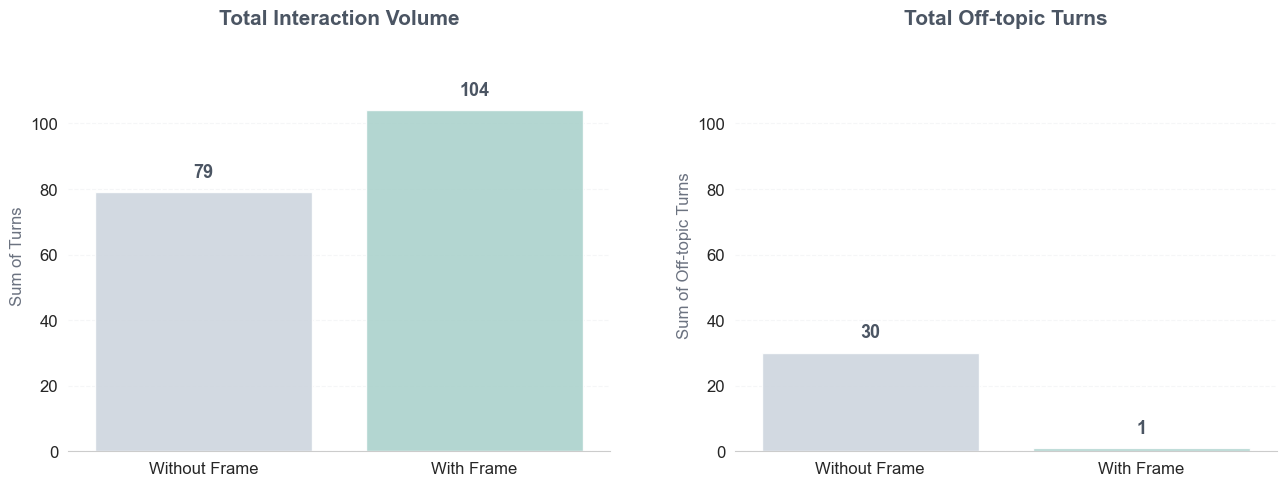

In [18]:
# --- DESIGNER PALETTE: PASTEL SLATE & SOFT AQUA ---
color_baseline = "#CBD5E1" # Pastel Slate Grey
color_frame    = "#A5D8D0" # Soft Pastel Mint/Aqua (Blue-Green shift)

# 1. Prepare data (totals)
comp_data = df_analysis[[
    'Number of Turns in Frame', 
    'Number of Turns in No Frame', 
    'Out of topic turns  with frame', 
    'Out of topic turns without Frame'
]].dropna()

totals = {
    'Turns (No Frame)': comp_data['Number of Turns in No Frame'].sum(),
    'Turns (With Frame)': comp_data['Number of Turns in Frame'].sum(),
    'Off-topic (No Frame)': comp_data['Out of topic turns without Frame'].sum(),
    'Off-topic (With Frame)': comp_data['Out of topic turns  with frame'].sum()
}

# Calculate the maximum value across ALL bars to set a uniform scale
all_values = list(totals.values())
max_val = max(all_values)
upper_limit = max_val * 1.15 # Add 15% head room for the numeric labels

# 2. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Total Number of Turns
turn_categories = ['Without Frame', 'With Frame']
turn_values = [totals['Turns (No Frame)'], totals['Turns (With Frame)']]

sns.barplot(x=turn_categories, y=turn_values, hue=turn_categories, 
            palette=[color_baseline, color_frame], ax=ax1, alpha=0.9, legend=False)

ax1.set_title("Total Interaction Volume", fontweight='bold', fontsize=15, pad=25, color='#4B5563')
ax1.set_ylabel("Sum of Turns", fontsize=12, color='#6B7280')
ax1.set_ylim(0, upper_limit) # Set uniform scale
ax1.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=13, color='#4B5563')

# Subplot 2: Total Number of Off-topic Turns
off_categories = ['Without Frame', 'With Frame']
off_values = [totals['Off-topic (No Frame)'], totals['Off-topic (With Frame)']]

sns.barplot(x=off_categories, y=off_values, hue=off_categories, 
            palette=[color_baseline, color_frame], ax=ax2, alpha=0.9, legend=False)

ax2.set_title("Total Off-topic Turns", fontweight='bold', fontsize=15, pad=25, color='#4B5563')
ax2.set_ylabel("Sum of Off-topic Turns", fontsize=12, color='#6B7280')
ax2.set_ylim(0, upper_limit) # Set uniform scale
ax2.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=13, color='#4B5563')

plt.tight_layout(pad=4.0)
plt.show()

# Balanced turns with GINI

STATISTICAL ANALYSIS: TURN BALANCE (GINI)

1. ANOVA Result (Difference in Means):
F-statistic: 2.7659
p-value:     0.1158
RESULT: No significant difference in average balance found.

2. Levene’s Test Result (Difference in Variance):
W-statistic: 9.3570
p-value:     0.0075
RESULT: The consistency (variance) of the balance is significantly different.
        (One condition is more reliable than the other).

3. Detailed ANOVA Table:


,sum_sq,df,F,PR(>F)
Condition,0.116735,1.0,2.765868,0.115756
Residual,0.675287,16.0,NaN,NaN


/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15186/2620048129.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Condition', y='Gini', palette=[color_baseline, color_frame], inner="quart")


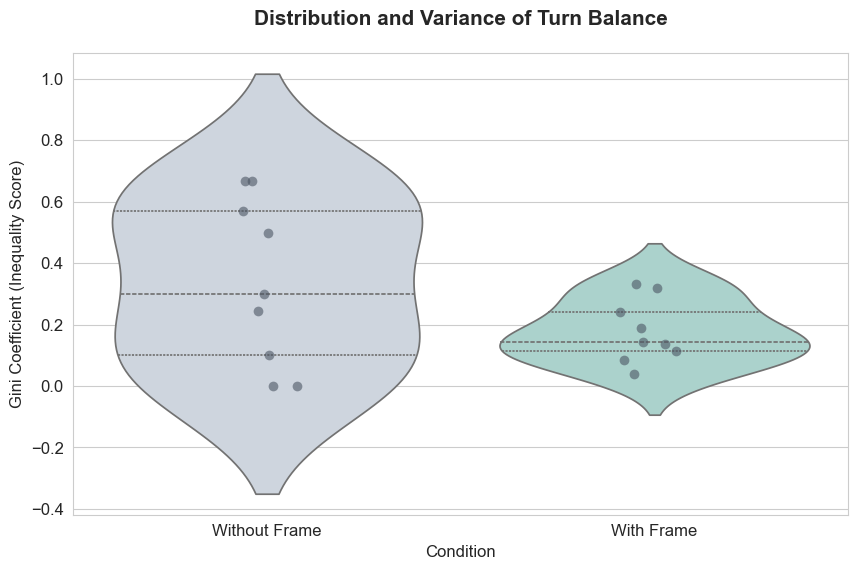

In [30]:
from scipy.stats import f_oneway, levene
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Prepare the data
# We use the df_plot (long format) created in the previous step
# df_plot has columns: ['Group', 'Condition', 'Gini']

# 2. ANOVA (Comparing the MEANS of the balance scores)
# This tells us: "On average, is one condition more balanced than the other?"
f_stat, p_anova = f_oneway(
    df_balance['balance_no_frame'], 
    df_balance['balance_with_frame']
)

# 3. Levene's Test (Comparing the VARIANCES of the balance scores)
# This tells us: "Is the balance more CONSISTENT in one condition vs the other?"
# (i.e., do some groups struggle a lot while others succeed, or are they all similar?)
l_stat, p_levene = levene(
    df_balance['balance_no_frame'], 
    df_balance['balance_with_frame'], 
    center='median' # 'median' is recommended for non-normal data
)

# 4. Detailed ANOVA table using statsmodels
model = ols('Gini ~ Condition', data=df_plot).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# --- Output Results ---
print("="*60)
print("STATISTICAL ANALYSIS: TURN BALANCE (GINI)")
print("="*60)

print("\n1. ANOVA Result (Difference in Means):")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_anova:.4f}")
if p_anova < 0.05:
    print("RESULT: There is a significant difference in the AVERAGE turn balance.")
else:
    print("RESULT: No significant difference in average balance found.")

print("\n2. Levene’s Test Result (Difference in Variance):")
print(f"W-statistic: {l_stat:.4f}")
print(f"p-value:     {p_levene:.4f}")
if p_levene < 0.05:
    print("RESULT: The consistency (variance) of the balance is significantly different.")
    print("        (One condition is more reliable than the other).")
else:
    print("RESULT: No significant difference in the consistency (variance) found.")

print("\n3. Detailed ANOVA Table:")
display(anova_table)

# 5. Visualizing the Variance (Spread)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='Condition', y='Gini', palette=[color_baseline, color_frame], inner="quart")
sns.stripplot(data=df_plot, x='Condition', y='Gini', color='#4B5563', alpha=0.6, size=7)

plt.title("Distribution and Variance of Turn Balance", fontweight='bold', fontsize=15, pad=20)
plt.ylabel("Gini Coefficient (Inequality Score)", fontsize=12)
plt.show()

/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15186/1079946776.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_plot, x='Condition', y='Gini',


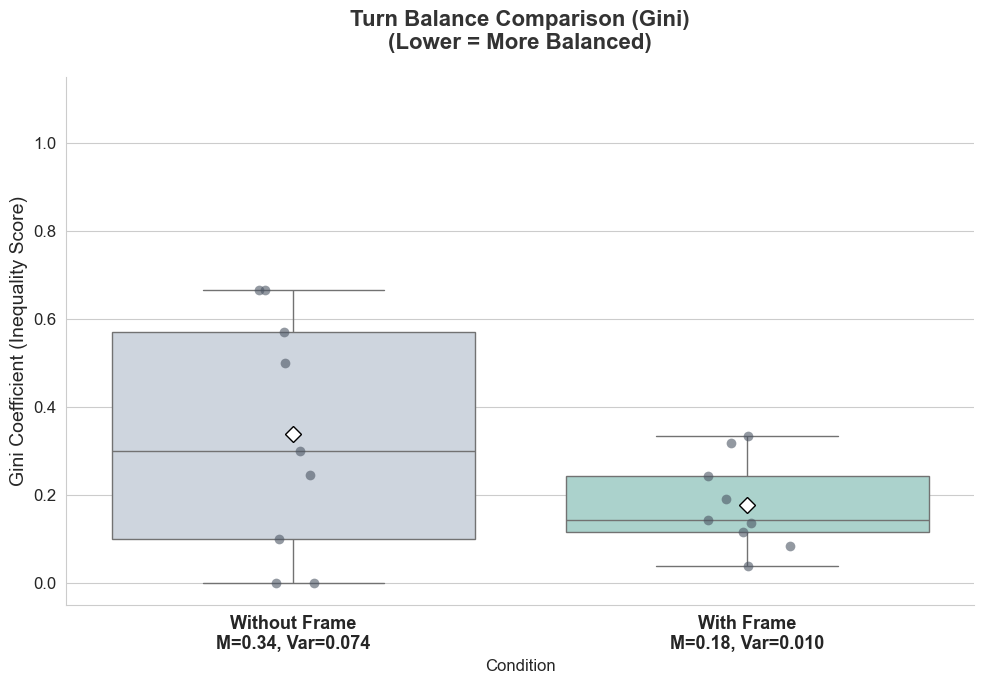

Wilcoxon test: p-value = 0.1289


In [31]:
import numpy as np
from scipy.stats import wilcoxon

# Function to calculate Gini Coefficient (Balance Score)
def gini(list_of_values):
    values = np.array(list_of_values)
    values = values[~np.isnan(values)] # Remove NA
    if len(values) == 0 or sum(values) == 0:
        return np.nan
    sorted_values = np.sort(values)
    n = len(values)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * sorted_values)) / (n * np.sum(sorted_values))

# 1. Select the last 6 columns and Group
s_cols_no = ['No Frame: student 1', 'No Frame: student 2', 'No Frame: student 3']
s_cols_with = ['With Frame: student 1', 'With Frame: student 2', 'With Frame: student 3']

# 2. Calculate Balance Scores for each condition
df_analysis['balance_no_frame'] = df_analysis[s_cols_no].apply(lambda x: gini(x), axis=1)
df_analysis['balance_with_frame'] = df_analysis[s_cols_with].apply(lambda x: gini(x), axis=1)

# Drop rows where we don't have comparison data
df_balance = df_analysis[['Group', 'balance_no_frame', 'balance_with_frame']].dropna()

# --- NEW: Calculate Stats for the Graph ---
mean_no = df_balance['balance_no_frame'].mean()
var_no = df_balance['balance_no_frame'].var()
mean_with = df_balance['balance_with_frame'].mean()
var_with = df_balance['balance_with_frame'].var()

# 3. Visualization
plt.figure(figsize=(10, 7))
color_baseline = "#CBD5E1" # Pastel Grey
color_frame    = "#A5D8D0" # Soft Aqua

# Reshape for plotting
df_plot = df_balance.melt(id_vars='Group', var_name='Condition', value_name='Gini')
df_plot['Condition'] = df_plot['Condition'].map({
    'balance_no_frame': 'Without Frame', 
    'balance_with_frame': 'With Frame'
})

# Create boxplot showing the mean as a white diamond
ax = sns.boxplot(data=df_plot, x='Condition', y='Gini', 
                 palette=[color_baseline, color_frame],
                 showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                 legend=False)

sns.stripplot(data=df_plot, x='Condition', y='Gini', color='#4B5563', alpha=0.6, size=7)

# Update X-axis labels to include Mean and Variance
plt.xticks(ticks=[0, 1], labels=[
    f"Without Frame\nM={mean_no:.2f}, Var={var_no:.3f}",
    f"With Frame\nM={mean_with:.2f}, Var={var_with:.3f}"
], fontsize=13, fontweight='bold')

plt.title("Turn Balance Comparison (Gini)\n(Lower = More Balanced)", fontweight='bold', fontsize=16, pad=20, color='#333333')
plt.ylabel("Gini Coefficient (Inequality Score)", fontsize=14)
plt.ylim(-0.05, 1.15) # Room for labels

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Statistical Testing
stat, p = wilcoxon(df_balance['balance_no_frame'], df_balance['balance_with_frame'])
print(f"Wilcoxon test: p-value = {p:.4f}")

/var/folders/q5/pk7qj5ls4j742f50_1901z000000gq/T/ipykernel_15186/2475212909.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_cocreation, x='Level', y='Score',


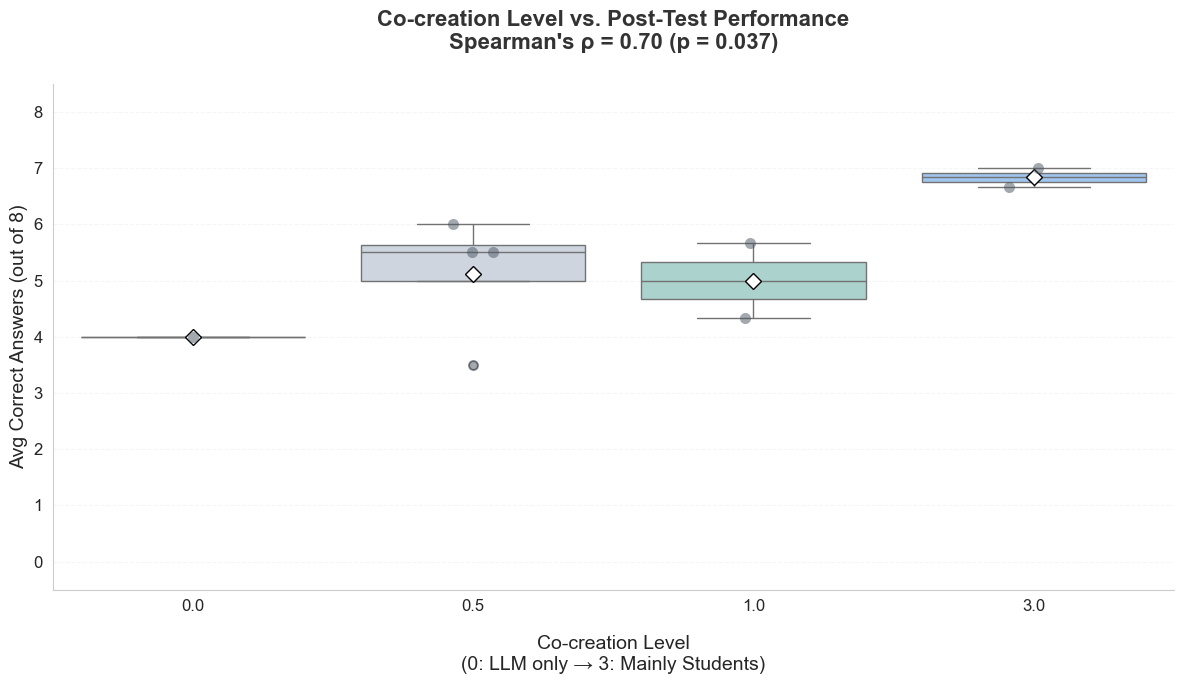

Analysis Summary:
Groups analyzed: 9
Level 0: Mean Score = 4.00 (n=1)
Level 0: Mean Score = 5.12 (n=4)
Level 1: Mean Score = 5.00 (n=2)
Level 3: Mean Score = 6.83 (n=2)


In [34]:
# 1. Prepare the data
# Using the exact long column names from your CSV
cocreation_col = "Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)"
score_col = "average nb of correct answers on LLM_Microcontollers (out of 8)"

# Extract and drop missing values
df_cocreation = df_analysis[[cocreation_col, score_col]].dropna()
df_cocreation.columns = ['Level', 'Score']

# 2. Statistical Analysis (Spearman Rank Correlation)
from scipy.stats import spearmanr
rho, p_val = spearmanr(df_cocreation['Level'], df_cocreation['Score'])

# 3. Visualization
plt.figure(figsize=(12, 7))

# Define a soft pastel sequence for the levels 0-3
pastel_palette = ["#E2E8F0", "#CBD5E1", "#A5D8D0", "#93C5FD"] 

ax = sns.boxplot(data=df_cocreation, x='Level', y='Score', 
                 palette=pastel_palette,
                 showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                 legend=False)

# Add individual group points
sns.stripplot(data=df_cocreation, x='Level', y='Score', color='#4B5563', alpha=0.5, size=8)

# Set labels and title
plt.title(f"Co-creation Level vs. Post-Test Performance\nSpearman's ρ = {rho:.2f} (p = {p_val:.3f})", 
          fontweight='bold', fontsize=16, pad=25, color='#333333')

plt.xlabel("Co-creation Level\n(0: LLM only → 3: Mainly Students)", fontsize=14, labelpad=15)
plt.ylabel("Avg Correct Answers (out of 8)", fontsize=14)
plt.ylim(-0.5, 8.5)

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)

plt.tight_layout()
plt.show()

# Print detailed summary
print("Analysis Summary:")
print(f"Groups analyzed: {len(df_cocreation)}")
for level in sorted(df_cocreation['Level'].unique()):
    mean_score = df_cocreation[df_cocreation['Level'] == level]['Score'].mean()
    count = len(df_cocreation[df_cocreation['Level'] == level])
    print(f"Level {int(level)}: Mean Score = {mean_score:.2f} (n={count})")

Analysis for the 2 specific Microcontroller questions:
Spearman rho = 0.275
p-value      = 0.475


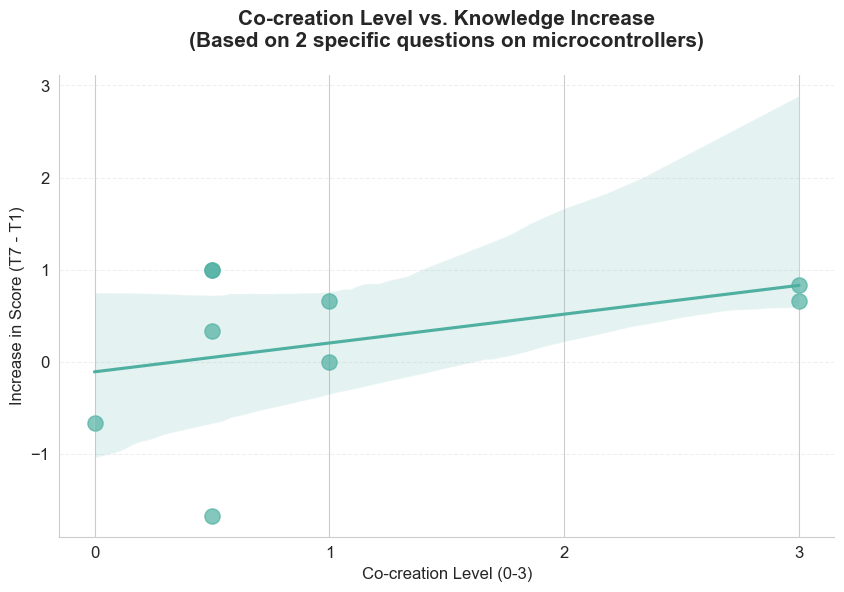

,Group,"Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)",T1_Avg_2q,T7_Avg_2q,learning_increase_2q
0,2,3.0,0.666667,1.500000,0.833333
1,3,1.0,0.333333,1.000000,0.666667
2,4,1.0,0.333333,0.333333,0.000000
3,5,0.5,0.000000,0.333333,0.333333
4,6,3.0,0.333333,1.000000,0.666667
5,7,0.5,1.666667,0.000000,-1.666667
6,8,0.5,0.000000,1.000000,1.000000
7,9,0.5,0.000000,1.000000,1.000000
8,10,0.0,0.666667,0.000000,-0.666667


In [38]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Mapping (Participant ID -> Group)
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')

# 2. Load the Knowledge Data
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# Helper function to score the 2 specific questions (1 = correct, else 0)
def score_mc_questions(df_subset):
    return (df_subset['microcontrollers_1'] == 1).astype(int) + \
           (df_subset['microcontrollers_2'] == 1).astype(int)

# 3. Extract and Score T1 and T7 for the SAME 2 questions
# T1 Scores
df_t1 = df_children[df_children['Timepoint'] == 'T1'].copy()
df_t1['score_2q'] = score_mc_questions(df_t1)

# T7 Scores
df_t7 = df_children[df_children['Timepoint'] == 'T7'].copy()
df_t7['score_2q'] = score_mc_questions(df_t7)

# 4. Aggregate to Group Level
# Merge mapping first to get Group IDs
df_t1_grp = df_t1.merge(mapping, on='Participant ID').groupby('Group')['score_2q'].mean().reset_index()
df_t1_grp.columns = ['Group', 'T1_Avg_2q']

df_t7_grp = df_t7.merge(mapping, on='Participant ID').groupby('Group')['score_2q'].mean().reset_index()
df_t7_grp.columns = ['Group', 'T7_Avg_2q']

# Merge T1 and T7 group averages
df_growth = df_t1_grp.merge(df_t7_grp, on='Group')
df_growth['learning_increase_2q'] = df_growth['T7_Avg_2q'] - df_growth['T1_Avg_2q']

# 5. Merge with Co-creation Level from Analysis CSV
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

# Final combined dataframe
df_final_2q = df_cocreat.merge(df_growth, on='Group', how='inner')

# 6. Calculate Correlation
rho, p = spearmanr(df_final_2q[cocreation_col], df_final_2q['learning_increase_2q'])

print(f"Analysis for the 2 specific Microcontroller questions:")
print(f"Spearman rho = {rho:.3f}")
print(f"p-value      = {p:.3f}")

# 7. Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=df_final_2q, x=cocreation_col, y='learning_increase_2q', 
            scatter_kws={'s':120, 'alpha':0.7}, color='#4FB0A2')

plt.title("Co-creation Level vs. Knowledge Increase\n(Based on 2 specific questions on microcontrollers)", fontweight='bold', fontsize=15, pad=20)
plt.xlabel("Co-creation Level (0-3)", fontsize=12)
plt.ylabel("Increase in Score (T7 - T1)", fontsize=12)
plt.xticks([0, 1, 2, 3])
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.show()

display(df_final_2q[['Group', cocreation_col, 'T1_Avg_2q', 'T7_Avg_2q', 'learning_increase_2q']])

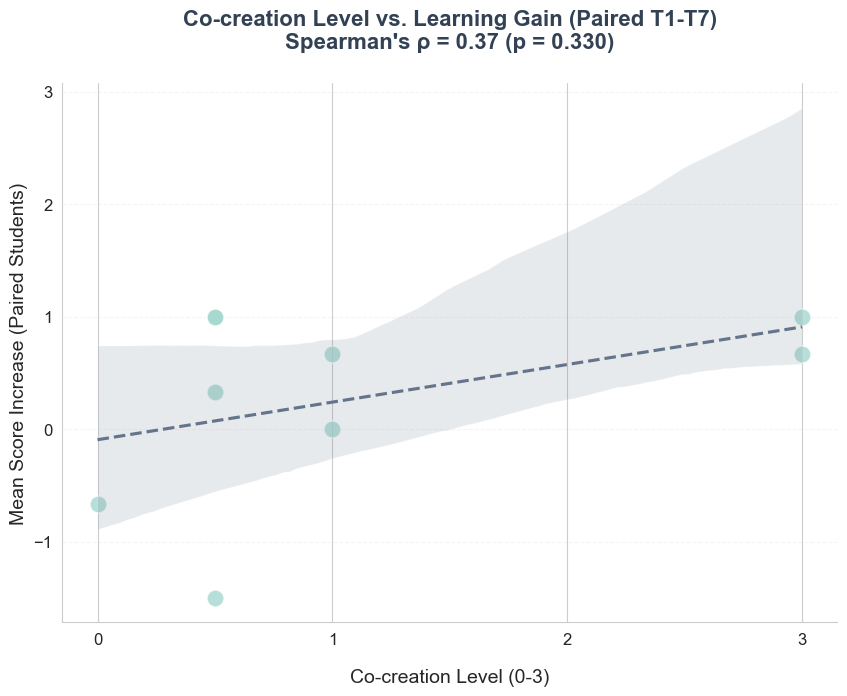

Paired students analyzed: 26
Groups included in final correlation: 9


In [40]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')

# 2. Clean Participant IDs
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# 3. isolate T1 and T7 knowledge data
df_t1 = df_children[df_children['Timepoint'] == 'T1'].copy()
df_t7 = df_children[df_children['Timepoint'] == 'T7'].copy()

# Score the 2 specific questions (1 = correct, else 0)
for df_tmp in [df_t1, df_t7]:
    df_tmp['mc_score'] = (df_tmp['microcontrollers_1'] == 1).astype(int) + (df_tmp['microcontrollers_2'] == 1).astype(int)

# 4. PAIRING: Keep only students present at BOTH T1 and T7
# This automatically removes students absent at T7
df_paired = df_t1[['Participant ID', 'mc_score']].merge(
    df_t7[['Participant ID', 'mc_score']], 
    on='Participant ID', 
    suffixes=('_T1', '_T7'),
    how='inner' # Only keeps participants in both dataframes
)

# Calculate individual learning gain
df_paired['indiv_gain'] = df_paired['mc_score_T7'] - df_paired['mc_score_T1']

# 5. Aggregate Paired Gains to Group Level
df_paired_with_grp = df_paired.merge(mapping, on='Participant ID')
df_group_growth = df_paired_with_grp.groupby('Group')['indiv_gain'].mean().reset_index()

# 6. Merge with Co-creation Level
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

df_final_paired = df_cocreat.merge(df_group_growth, on='Group', how='inner')

# 7. Statistics & Visualization
rho, p = spearmanr(df_final_paired[cocreation_col], df_final_paired['indiv_gain'])

plt.figure(figsize=(10, 7))
color_frame = "#A5D8D0" # Soft Pastel Aqua

ax = sns.regplot(data=df_final_paired, x=cocreation_col, y='indiv_gain', 
                 scatter_kws={'s':150, 'alpha':0.8, 'edgecolor':'white'}, 
                 line_kws={'color': '#64748B', 'linestyle':'--'}, 
                 color=color_frame)

plt.title(f"Co-creation Level vs. Learning Gain (Paired T1-T7)\nSpearman's ρ = {rho:.2f} (p = {p:.3f})", 
          fontweight='bold', fontsize=16, pad=25, color='#334155')

plt.xlabel("Co-creation Level (0-3)", fontsize=14, labelpad=15)
plt.ylabel("Mean Score Increase (Paired Students)", fontsize=14)
plt.xticks([0, 1, 2, 3], fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.2)
sns.despine()
plt.show()

print(f"Paired students analyzed: {len(df_paired)}")
print(f"Groups included in final correlation: {len(df_final_paired)}")

--- KNOWLEDGE EVOLUTION CORRELATIONS ---
T1 vs T4: rho = -0.45, p = 0.223
T4 vs T7: rho = 0.30, p = 0.434
T1 vs T7: rho = -0.69, p = 0.041

--- CO-CREATION CORRELATIONS ---
T1 Knowledge vs. Co-creation Level: rho = -0.17, p = 0.665
T7 Knowledge vs. Co-creation Level: rho = 0.67, p = 0.048


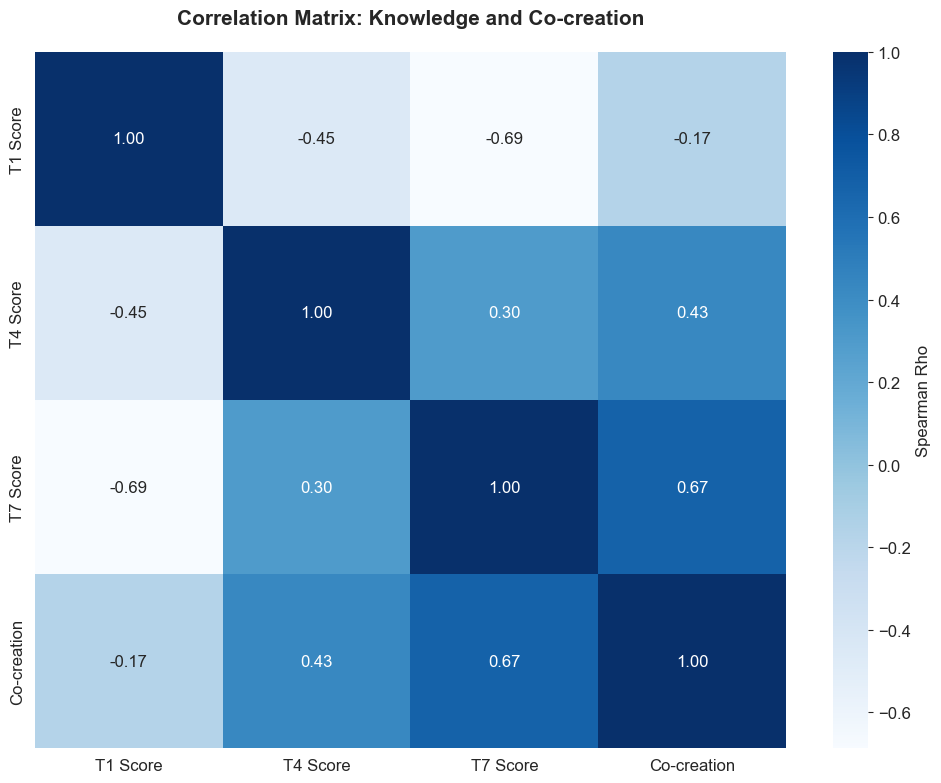

,Group,"Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)",score_T1,score_T4,score_T7
0,2,3.0,0.000000,1.000000,2.000000
1,3,1.0,0.333333,0.666667,1.000000
2,4,1.0,0.333333,1.000000,0.333333
3,5,0.5,0.000000,1.000000,0.333333
4,6,3.0,0.333333,0.666667,1.000000
5,7,0.5,1.500000,0.500000,0.000000
6,8,0.5,0.000000,1.000000,1.000000
7,9,0.5,0.000000,0.000000,1.000000
8,10,0.0,0.666667,0.333333,0.000000


In [41]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_eng = pd.read_csv('Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv', encoding='ISO-8859-1')
df_children = pd.read_csv('Data/Qualtrics/BuildBots_children_T1T4T7.csv')

# 2. Setup IDs and Group Mapping
mapping = df_eng[['Participant ID', 'Group']].drop_duplicates()
mapping['Participant ID'] = pd.to_numeric(mapping['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')

# 3. isolate and Score Knowledge for T1, T4, and T7
def get_scores(timepoint):
    subset = df_children[df_children['Timepoint'] == timepoint].copy()
    # Correct = 1, anything else = 0
    subset[f'score_{timepoint}'] = (subset['microcontrollers_1'] == 1).astype(int) + \
                                   (subset['microcontrollers_2'] == 1).astype(int)
    return subset[['Participant ID', f'score_{timepoint}']]

df_t1_scores = get_scores('T1')
df_t4_scores = get_scores('T4')
df_t7_scores = get_scores('T7')

# 4. Merge Knowledge Timepoints (Student Level)
df_knowledge_all = df_t1_scores.merge(df_t4_scores, on='Participant ID', how='inner')\
                               .merge(df_t7_scores, on='Participant ID', how='inner')

# 5. Aggregate to Group Level (Means)
df_group_know = df_knowledge_all.merge(mapping, on='Participant ID')\
                                .groupby('Group')[['score_T1', 'score_T4', 'score_T7']].mean().reset_index()

# 6. Merge with Co-creation Level from Analysis CSV
df_analysis_raw = pd.read_csv('Data/BuildbotAnalysis - LLM analysis.csv', skiprows=1)
df_analysis_raw.columns = [col.replace('\n', ' ').strip() for col in df_analysis_raw.columns]

cocreation_col = 'Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)'
df_cocreat = df_analysis_raw[['Group', cocreation_col]].dropna()
df_cocreat['Group'] = pd.to_numeric(df_cocreat['Group'], errors='coerce')

# Final Dataframe for correlation
df_final_all = df_cocreat.merge(df_group_know, on='Group', how='inner')

# 7. RUN CORRELATIONS
print("--- KNOWLEDGE EVOLUTION CORRELATIONS ---")
t1_t4_rho, t1_t4_p = spearmanr(df_final_all['score_T1'], df_final_all['score_T4'])
t4_t7_rho, t4_t7_p = spearmanr(df_final_all['score_T4'], df_final_all['score_T7'])
t1_t7_rho, t1_t7_p = spearmanr(df_final_all['score_T1'], df_final_all['score_T7'])

print(f"T1 vs T4: rho = {t1_t4_rho:.2f}, p = {t1_t4_p:.3f}")
print(f"T4 vs T7: rho = {t4_t7_rho:.2f}, p = {t4_t7_p:.3f}")
print(f"T1 vs T7: rho = {t1_t7_rho:.2f}, p = {t1_t7_p:.3f}")

print("\n--- CO-CREATION CORRELATIONS ---")
t1_coc_rho, t1_coc_p = spearmanr(df_final_all['score_T1'], df_final_all[cocreation_col])
t7_coc_rho, t7_coc_p = spearmanr(df_final_all['score_T7'], df_final_all[cocreation_col])

print(f"T1 Knowledge vs. Co-creation Level: rho = {t1_coc_rho:.2f}, p = {t1_coc_p:.3f}")
print(f"T7 Knowledge vs. Co-creation Level: rho = {t7_coc_rho:.2f}, p = {t7_coc_p:.3f}")

# 8. Visualization: Heatmap of all relationships
plt.figure(figsize=(10, 8))
corr_matrix = df_final_all[['score_T1', 'score_T4', 'score_T7', cocreation_col]].corr(method='spearman')
labels = ['T1 Score', 'T4 Score', 'T7 Score', 'Co-creation']

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f",
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Spearman Rho'})

plt.title("Correlation Matrix: Knowledge and Co-creation", fontweight='bold', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

display(df_final_all)

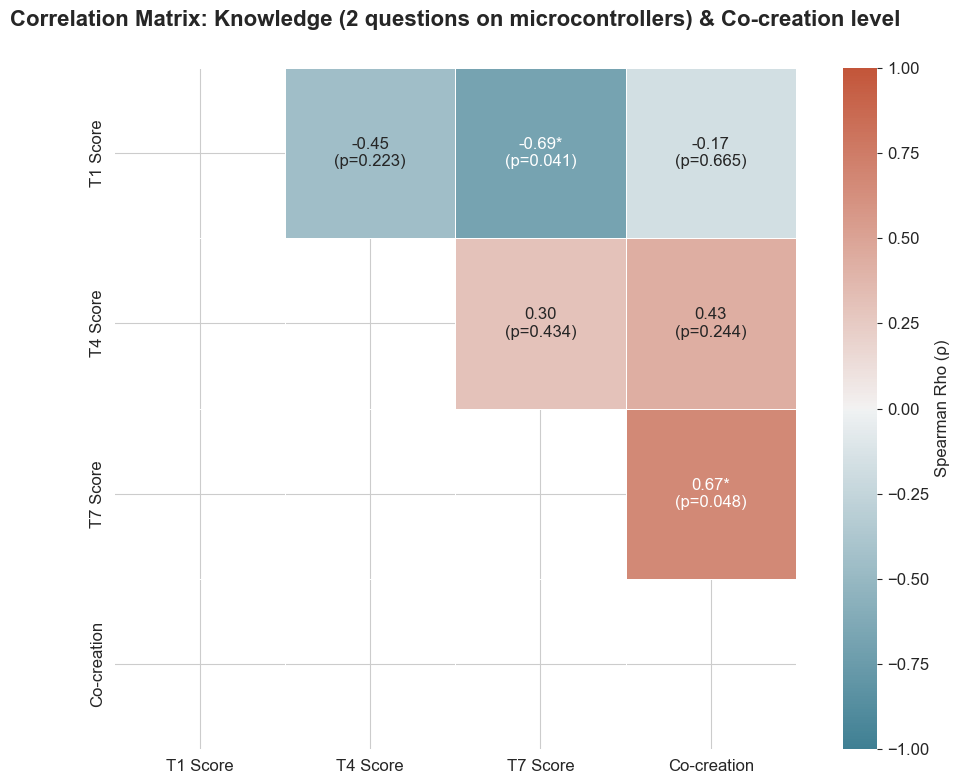

In [44]:
import numpy as np

# 1. Prepare the Correlation and P-value Matrices
cols_for_corr = ['score_T1', 'score_T4', 'score_T7', cocreation_col]
labels = ['T1 Score', 'T4 Score', 'T7 Score', 'Co-creation']

# Calculate Spearman Rho and P-values
corr_matrix = np.zeros((len(cols_for_corr), len(cols_for_corr)))
p_matrix = np.zeros((len(cols_for_corr), len(cols_for_corr)))

for i, col1 in enumerate(cols_for_corr):
    for j, col2 in enumerate(cols_for_corr):
        rho, p = spearmanr(df_final_all[col1], df_final_all[col2])
        corr_matrix[i, j] = rho
        p_matrix[i, j] = p

# 2. Create the annotations (Rho + P-value in parentheses)
annot_matrix = []
for i in range(len(cols_for_corr)):
    row = []
    for j in range(len(cols_for_corr)):
        star = "*" if p_matrix[i, j] < 0.05 else ""
        label = f"{corr_matrix[i, j]:.2f}{star}\n(p={p_matrix[i, j]:.3f})"
        row.append(label)
    annot_matrix.append(row)

# 3. Visualization: Half Matrix (FLIPPED - showing upper triangle)
plt.figure(figsize=(10, 8))

# Create a mask for the LOWER triangle (this shows the UPPER triangle)
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

# Set up color palette (Coolwarm or Blues)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=np.array(annot_matrix), 
            fmt="", 
            cmap=cmap, 
            center=0,
            vmin=-1, vmax=1,
            xticklabels=labels, 
            yticklabels=labels, 
            cbar_kws={'label': 'Spearman Rho (ρ)'},
            square=True,
            linewidths=.5)

plt.title("Correlation Matrix: Knowledge (2 questions on microcontrollers) & Co-creation level", fontweight='bold', fontsize=16, pad=30)
plt.tight_layout()
plt.show()
